## Análisis estadístico de señales 
## ECG: análisis en el dominio del tiempo

Sofía Cedeño Vargas - Mariana Paulina Vargas


1. Importación de librerías y datos

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
from scipy.signal import find_peaks

#Cargar archivo .mat
data = sio.loadmat("signals.mat")

#Frecuencia de muestreo
Fs = float(data["Fs"].squeeze())

#ECG sin filtrar y filtrado
ecg = np.squeeze(data["ECG_asRecording"]).astype(float)
ecg_filtered = np.squeeze(data["ECG_filtered"]).astype(float)

print(f"Frecuencia de muestreo: {Fs:.0f} Hz")
print(f"Número de muestras ECG: {len(ecg)}")
print(f"Número de muestras ECG filtrado: {len(ecg_filtered)}")

Frecuencia de muestreo: 1024 Hz
Número de muestras ECG: 30720
Número de muestras ECG filtrado: 30720


2. Implementación de la función RMS

Para una señal discreta \(x[n]\) con \(N\) muestras:

\[
RMS = \sqrt{\frac{1}{N}\sum_{n=1}^{N}x[n]^2}
\]

El RMS siempre es no negativo y representa una medida de la magnitud efectiva de la señal.

In [ ]:
def calcular_rms(x):
    #Convertir la entrada a arreglo numérico
    x = np.asarray(x, dtype=float)

    #Calcular valor cuadrático medio
    return np.sqrt(np.mean(x**2))

#Prueba rápida de la función
print("RMS del ECG sin filtrar:", calcular_rms(ecg))
print("RMS del ECG filtrado:", calcular_rms(ecg_filtered))

RMS del ECG sin filtrar: 4392.9682937490725
RMS del ECG filtrado: 286.30557115249496


3. Duración de la señal y vector de tiempo

In [3]:
#Duración total del registro
N = len(ecg)
duracion = N / Fs

#Vector de tiempo: una posición temporal por muestra
t = np.arange(N) / Fs

print(f"Número de muestras: {N}")
print(f"Frecuencia de muestreo: {Fs:.0f} Hz")
print(f"Duración de la señal: {duracion:.2f} s")
print(f"Tiempo inicial: {t[0]:.6f} s")
print(f"Tiempo final de la última muestra: {t[-1]:.6f} s")

Número de muestras: 30720
Frecuencia de muestreo: 1024 Hz
Duración de la señal: 30.00 s
Tiempo inicial: 0.000000 s
Tiempo final de la última muestra: 29.999023 s


Resultado

El registro ECG contiene **30720 muestras** y fue adquirido a **1024 Hz**, por lo que:

La duración del registro es **30 s**. 

4. ECG sin filtrar y ECG filtrado

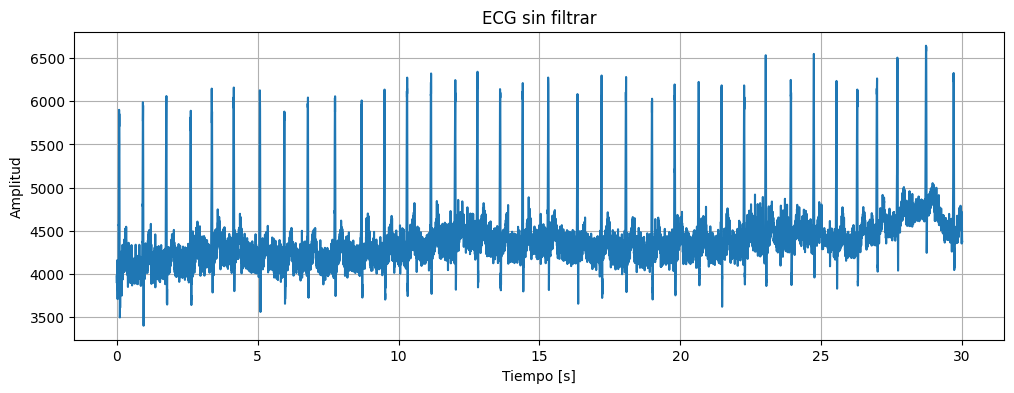

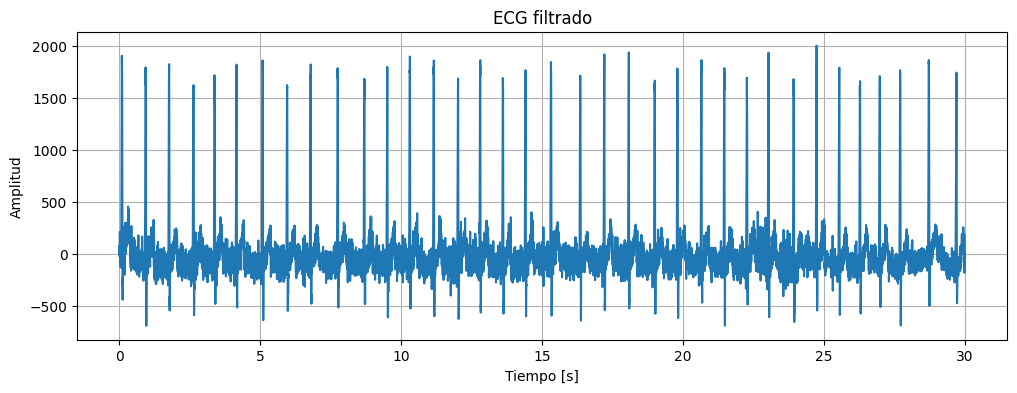

In [4]:
plt.figure(figsize=(12, 4))
plt.plot(t, ecg)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title("ECG sin filtrar")
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(t, ecg_filtered)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title("ECG filtrado")
plt.grid(True)
plt.show()

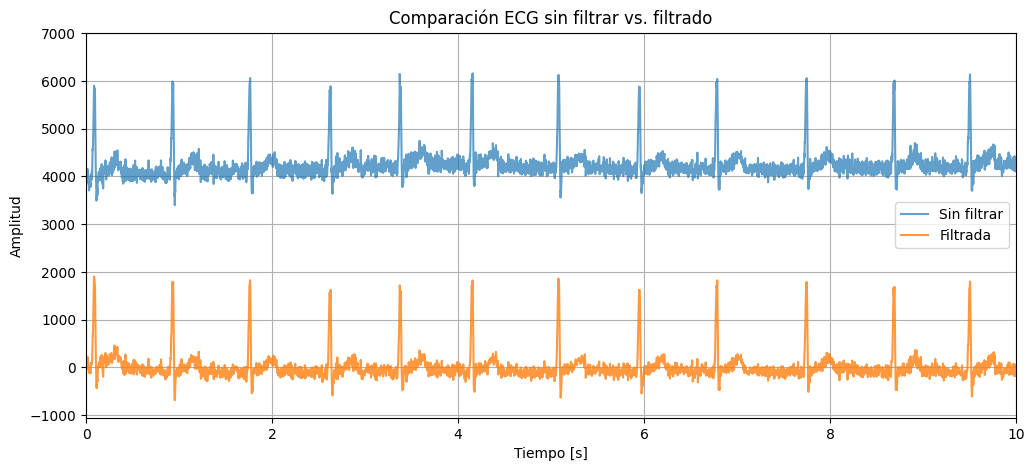

In [ ]:
#Comparación en los primeros 10 segundos
plt.figure(figsize=(12, 5))
plt.plot(t, ecg, label="Sin filtrar", alpha=0.7)
plt.plot(t, ecg_filtered, label="Filtrada", alpha=0.8)
plt.xlim(0, 10)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title("Comparación ECG sin filtrar vs. filtrado")
plt.legend()
plt.grid(True)
plt.show()

Análisis

Al comparar ambas señales se observa que el filtrado reduce componentes no deseadas presentes en el registro original. En particular, la señal filtrada queda centrada alrededor de valores cercanos a cero, mientras que la señal sin filtrar presenta un nivel de referencia elevado.

También se observa una reducción del ruido de alta frecuencia y una conservación clara de los complejos QRS, que son los eventos de mayor amplitud del ECG.

**Comportamiento esperado del filtro:** debe conservar las componentes de frecuencia relevantes para la morfología del ECG y atenuar componentes no deseadas, como deriva de línea base y ruido de alta frecuencia. Se pide recordar las frecuencias de interés del ECG, pero  no se proporcionan los valores de corte específicos del filtro usado; por eso no se debe afirmar un tipo o frecuencia de corte concreta sin consultar el diseño del filtro.

5. Selección de un ciclo cardiaco

Para seleccionar los ciclos de forma reproducible se detectan los picos R en la señal filtrada. Cada intervalo entre dos picos R consecutivos se toma como un ciclo R–R.

Esto permite seleccionar un ciclo completo y utilizar exactamente los mismos límites temporales en la señal sin filtrar y en la señal filtrada.


In [6]:
#Detección de picos R en la señal filtrada
picos_R, propiedades = find_peaks(
    ecg_filtered,
    distance=int(0.5 * Fs),
    prominence=500
)

print("Número de picos R detectados:", len(picos_R))
print("Primeros picos R (muestras):", picos_R[:10])

#Primer ciclo completo: entre el primer y segundo pico R
inicio = picos_R[0]
fin = picos_R[1]

ciclo_raw = ecg[inicio:fin]
ciclo_filtered = ecg_filtered[inicio:fin]
t_ciclo = np.arange(inicio, fin) / Fs

print(f"Inicio del ciclo: {inicio} muestras = {inicio/Fs:.4f} s")
print(f"Fin del ciclo: {fin} muestras = {fin/Fs:.4f} s")
print(f"Duración del ciclo: {(fin-inicio)/Fs:.4f} s")

Número de picos R detectados: 36
Primeros picos R (muestras): [  88  952 1806 2693 3454 4256 5201 6090 6950 7936]
Inicio del ciclo: 88 muestras = 0.0859 s
Fin del ciclo: 952 muestras = 0.9297 s
Duración del ciclo: 0.8438 s


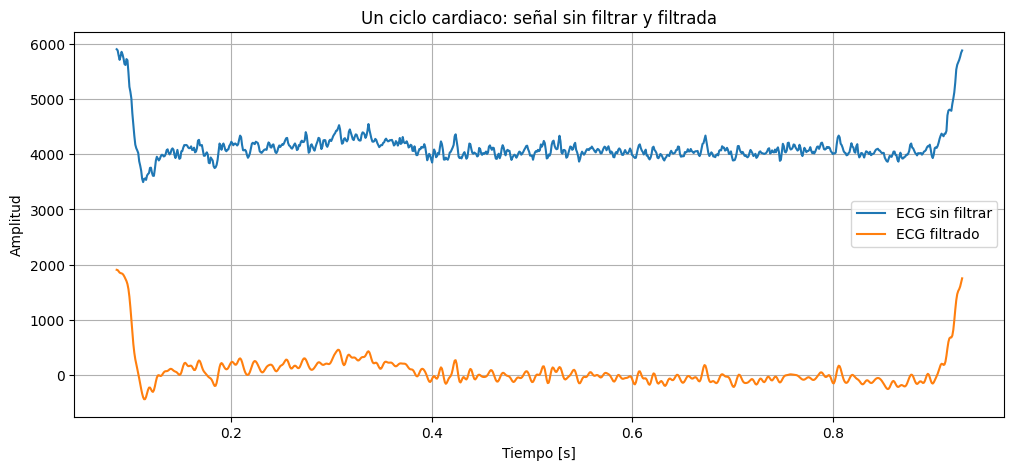

In [7]:
plt.figure(figsize=(12, 5))
plt.plot(t_ciclo, ciclo_raw, label="ECG sin filtrar")
plt.plot(t_ciclo, ciclo_filtered, label="ECG filtrado")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title("Un ciclo cardiaco: señal sin filtrar y filtrada")
plt.legend()
plt.grid(True)
plt.show()


6. Promedio, RMS, varianza y desviación estándar del ciclo

In [8]:
def estadisticas_senal(x):
    x = np.asarray(x, dtype=float)
    return {
        "Promedio": np.mean(x),
        "RMS": calcular_rms(x),
        "Varianza": np.var(x),
        "Desviación estándar": np.std(x)
    }

estadisticas_raw = estadisticas_senal(ciclo_raw)
estadisticas_filtered = estadisticas_senal(ciclo_filtered)

print("CICLO SIN FILTRAR")
for nombre, valor in estadisticas_raw.items():
    print(f"{nombre}: {valor:.4f}")

print("\nCICLO FILTRADO")
for nombre, valor in estadisticas_filtered.items():
    print(f"{nombre}: {valor:.4f}")


CICLO SIN FILTRAR
Promedio: 4129.0676
RMS: 4139.9580
Varianza: 90052.8583
Desviación estándar: 300.0881

CICLO FILTRADO
Promedio: 74.0100
RMS: 319.6276
Varianza: 96684.3149
Desviación estándar: 310.9410


Resultados del ciclo seleccionado

Para el primer intervalo R–R completo detectado:

| Medida | Sin filtrar | Filtrado |
|---|---:|---:|
| Promedio | 4129.0676 | 74.0100 |
| RMS | 4139.9580 | 319.6276 |
| Varianza | 90052.8583 | 96684.3149 |
| Desviación estándar | 300.0881 | 310.9410 |

Interpretación

El promedio cambia de forma marcada después del filtrado porque el registro original presenta un nivel de línea base elevado, mientras que el filtrado elimina gran parte de ese componente. Por esta razón, el RMS del registro sin filtrar está fuertemente influenciado por el nivel DC/desplazamiento de la señal.

La varianza y la desviación estándar describen la dispersión de las muestras alrededor de su promedio. En este ciclo, sus valores son del mismo orden antes y después del filtrado, aunque pueden cambiar debido a la eliminación de componentes de ruido.


7. Extracción de 15 ciclos de la señal filtrada

In [9]:
#Extraer los primeros 15 ciclos R-R completos
n_ciclos = 15
ciclos = []
estadisticas_15 = []

for i in range(n_ciclos):
    a = picos_R[i]
    b = picos_R[i + 1]
    ciclo = ecg_filtered[a:b]

    ciclos.append(ciclo)
    estadisticas_15.append({
        "Ciclo": i + 1,
        "Inicio [s]": a / Fs,
        "Fin [s]": b / Fs,
        "Duración [s]": (b - a) / Fs,
        "Promedio": np.mean(ciclo),
        "Varianza": np.var(ciclo),
        "Desv. estándar": np.std(ciclo),
        "RMS": calcular_rms(ciclo)
    })

import pandas as pd
tabla_15 = pd.DataFrame(estadisticas_15)
tabla_15


,Ciclo,Inicio [s],Fin [s],Duración [s],Promedio,Varianza,Desv. estándar,RMS
0,1,0.085938,0.929688,0.843750,74.009958,96684.314882,310.941015,319.627578
1,2,0.929688,1.763672,0.833984,-1.462578,104790.465489,323.713555,323.716859
2,3,1.763672,2.629883,0.866211,-10.433000,82451.251079,287.143259,287.332731
3,4,2.629883,3.373047,0.743164,-20.975178,46839.019694,216.423242,217.437296
4,5,3.373047,4.156250,0.783203,40.871105,114850.020065,338.895294,341.350944
5,6,4.156250,5.079102,0.922852,-27.943734,58147.589512,241.138113,242.751811
6,7,5.079102,5.947266,0.868164,0.430787,77707.281202,278.760258,278.760590
7,8,5.947266,6.787109,0.839844,21.407853,100268.181528,316.651514,317.374349
8,9,6.787109,7.750000,0.962891,-10.175290,71784.955786,267.927146,268.120294
9,10,7.750000,8.692383,0.942383,8.812103,68481.059763,261.688861,261.837188


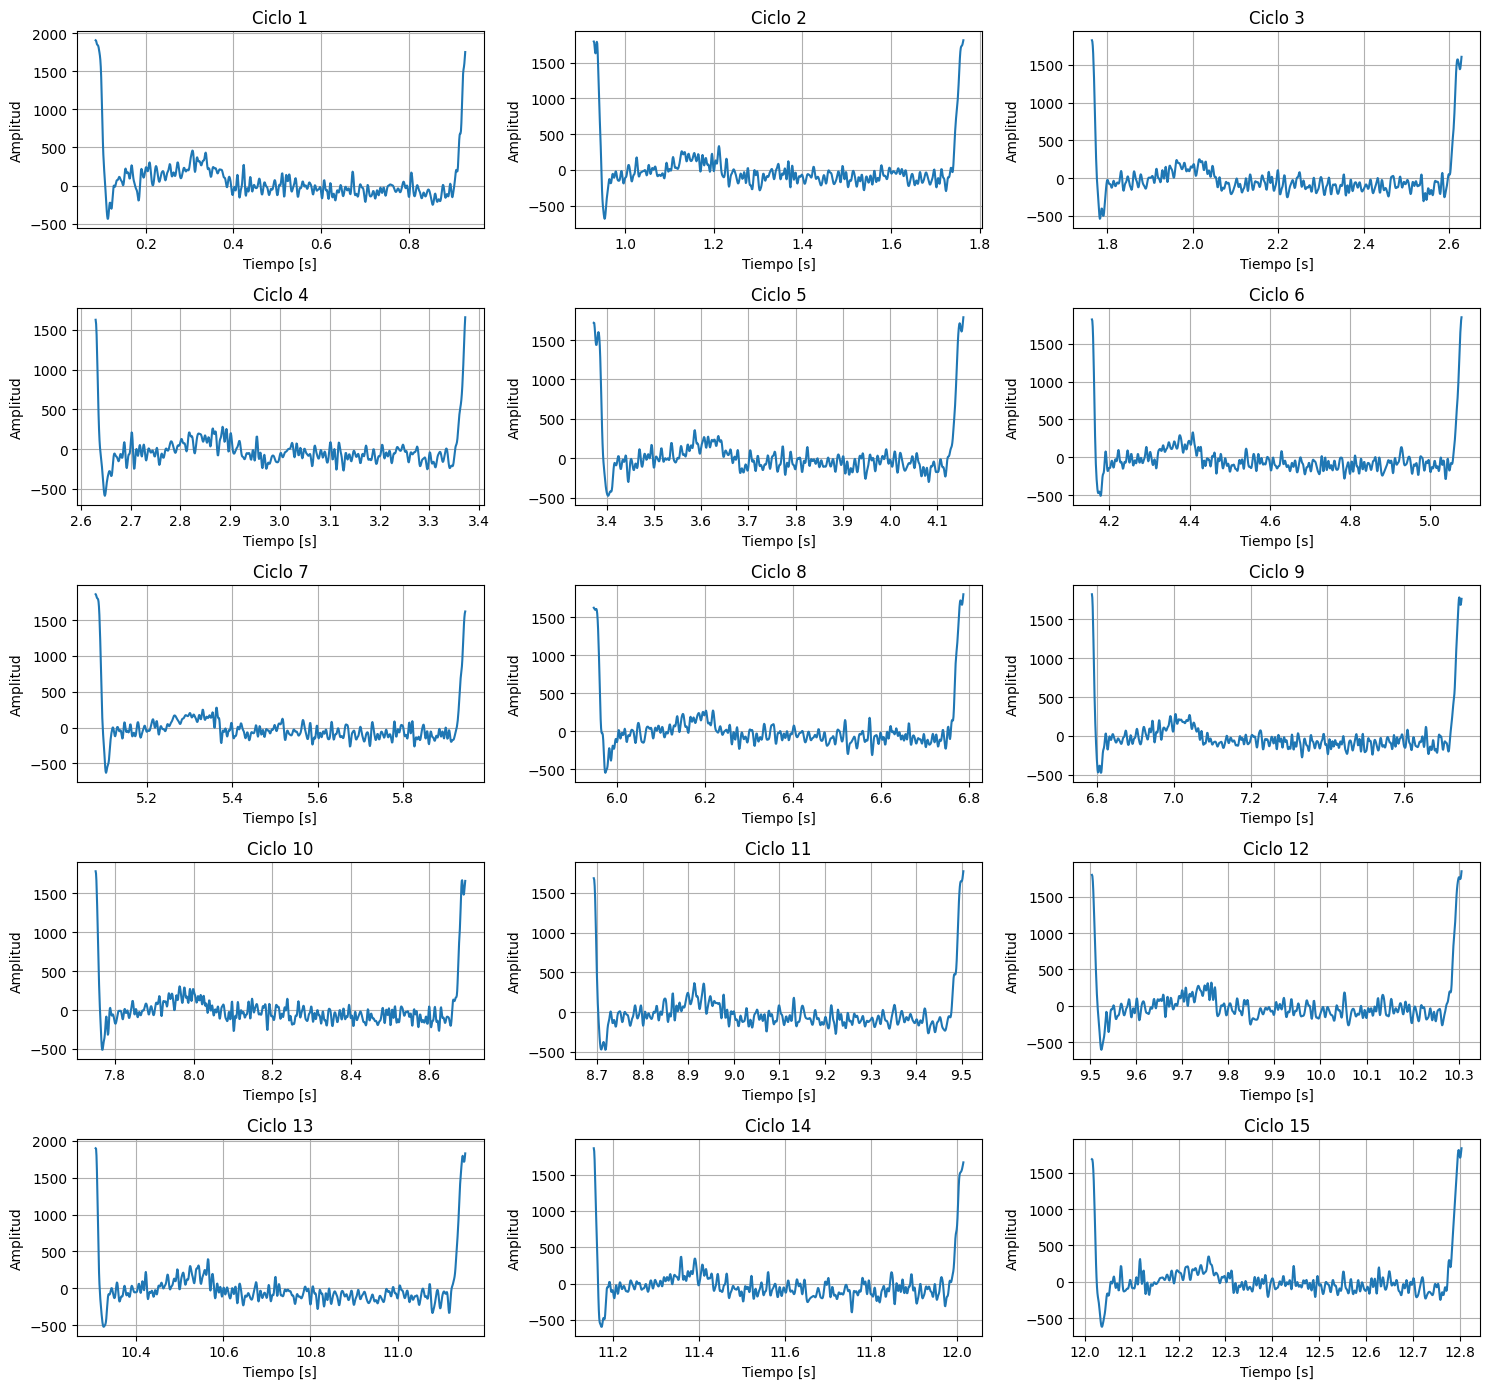

In [10]:
#Graficar los 15 ciclos en función del tiempo real
fig, axes = plt.subplots(5, 3, figsize=(15, 14))
axes = axes.ravel()

for i, ciclo in enumerate(ciclos):
    a = picos_R[i]
    b = picos_R[i + 1]
    t_local = np.arange(a, b) / Fs

    axes[i].plot(t_local, ciclo)
    axes[i].set_title(f"Ciclo {i+1}")
    axes[i].set_xlabel("Tiempo [s]")
    axes[i].set_ylabel("Amplitud")
    axes[i].grid(True)

plt.tight_layout()
plt.show()


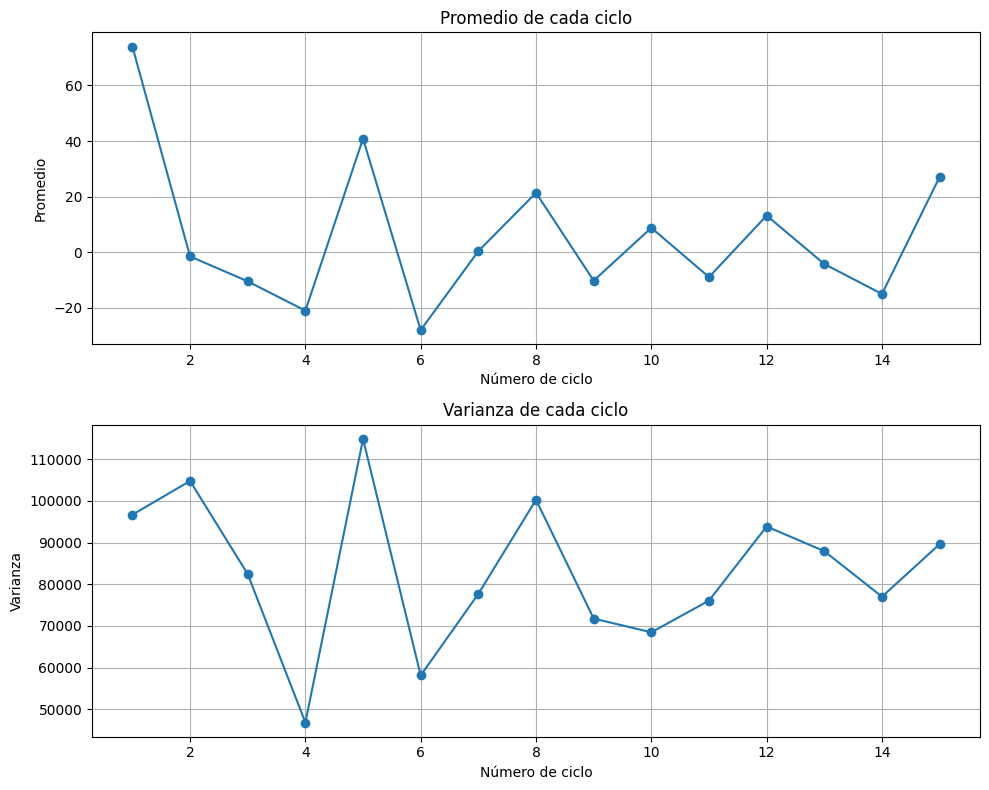

In [11]:
#Comparación gráfica de promedio y varianza de los 15 ciclos
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

axes[0].plot(tabla_15["Ciclo"], tabla_15["Promedio"], marker="o")
axes[0].set_xlabel("Número de ciclo")
axes[0].set_ylabel("Promedio")
axes[0].set_title("Promedio de cada ciclo")
axes[0].grid(True)

axes[1].plot(tabla_15["Ciclo"], tabla_15["Varianza"], marker="o")
axes[1].set_xlabel("Número de ciclo")
axes[1].set_ylabel("Varianza")
axes[1].set_title("Varianza de cada ciclo")
axes[1].grid(True)

plt.tight_layout()
plt.show()


Análisis gráfico y estadístico de los 15 ciclos

La comparación debe hacerse observando dos aspectos:

1. **Morfología:** si las formas de los ciclos son visualmente similares o presentan cambios importantes.
2. **Estadísticos:** si los promedios y las varianzas permanecen aproximadamente constantes.

En este registro, los ciclos presentan una morfología general semejante, aunque existen variaciones en amplitud, duración y ruido. Los valores de promedio y varianza tampoco son exactamente iguales entre ciclos.

**Conclusión preliminar:** la señal puede tratarse como aproximadamente estable durante el intervalo analizado para algunos propósitos descriptivos, pero no debe afirmarse rigurosamente que es estacionaria únicamente a partir de estas gráficas. La estacionariedad debe evaluarse estadística/probabilísticamente y posteriormente realizar pruebas t y Dickey-Fuller.

Por tanto, la conclusión definitiva sobre estacionariedad se realiza posteriormente.


## 8. Resumen de resultados al momento

- Frecuencia de muestreo: **1024 Hz**.
- Número de muestras ECG: **30720**.
- Duración del registro: **30 s**.
- Se implementó una función propia para calcular el **RMS**.
- Se construyó el vector de tiempo.
- Se comparó el ECG sin filtrar con el filtrado.
- Se seleccionó un ciclo cardiaco usando intervalos R–R.
- Se calcularon promedio, RMS, varianza y desviación estándar del ciclo.
- Se extrajeron 15 ciclos de la señal filtrada y se calcularon sus estadísticos.